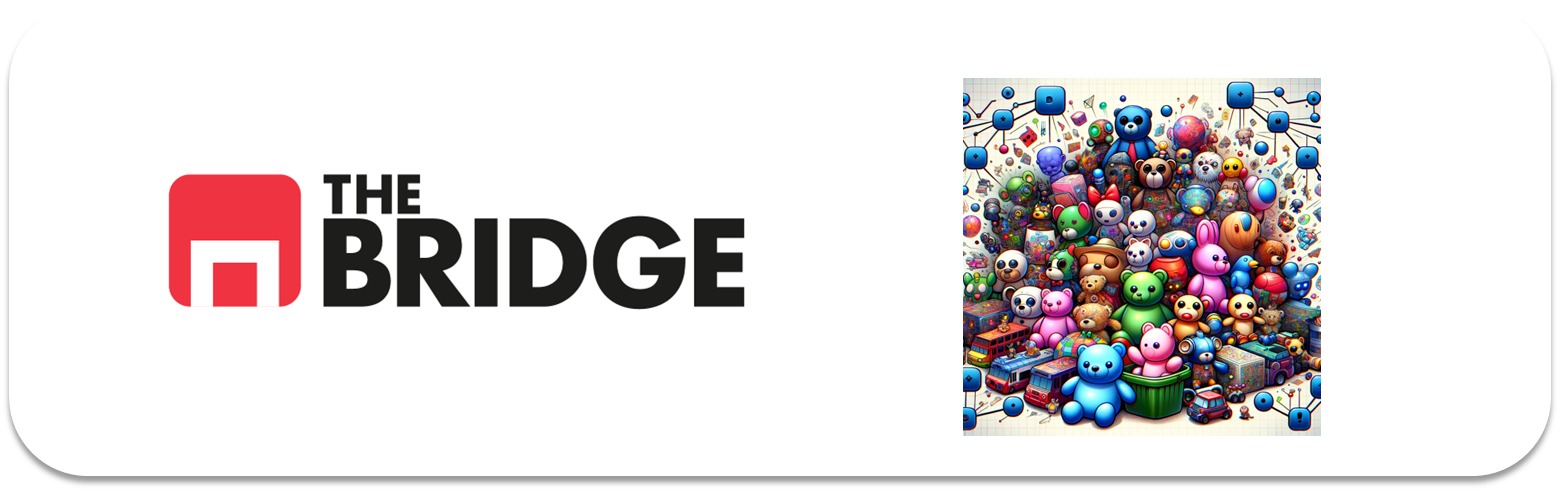

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### 1. Entender el problema

### 2. Carga y visualización

In [27]:
df_empow = pd.read_csv("./data/empowering_drinks.csv", sep="|")
df = df_empow.copy()

print(f"Shape: {df.shape}")



df.head()


Shape: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [28]:

df.describe()


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [29]:
# Comprobamos valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")


Valores nulos por columna:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

Total nulos: 0


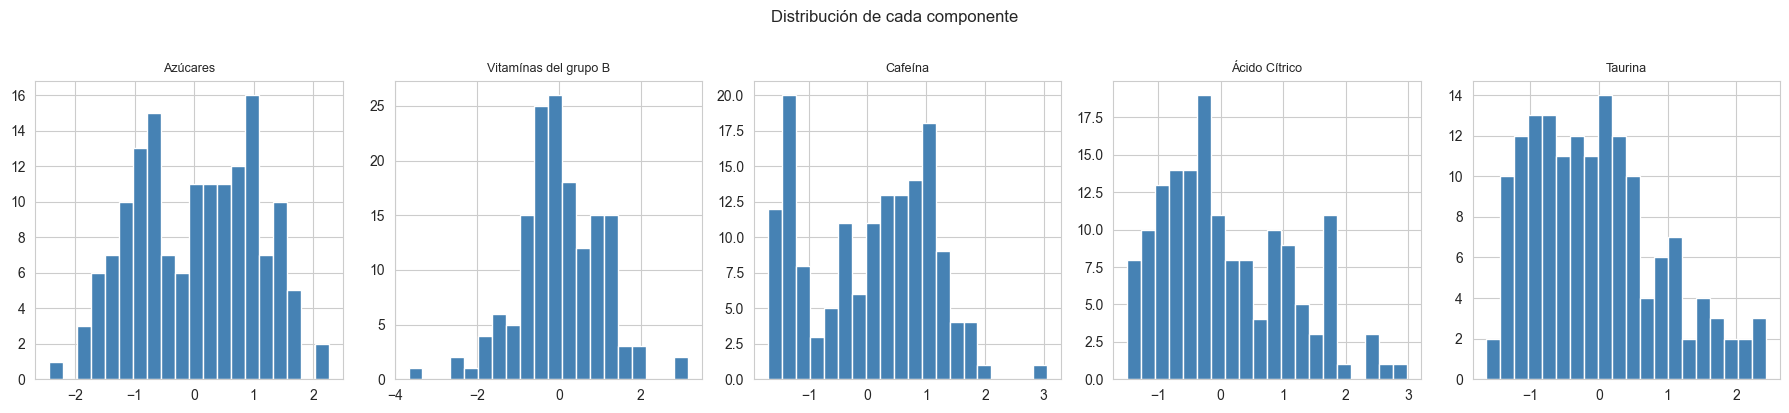

In [30]:
# Distribución de cada variable
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, df.columns):
    ax.hist(df[col], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=9)
plt.suptitle("Distribución de cada componente", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 3. Mini-EDA — Visualización de features dos a dos

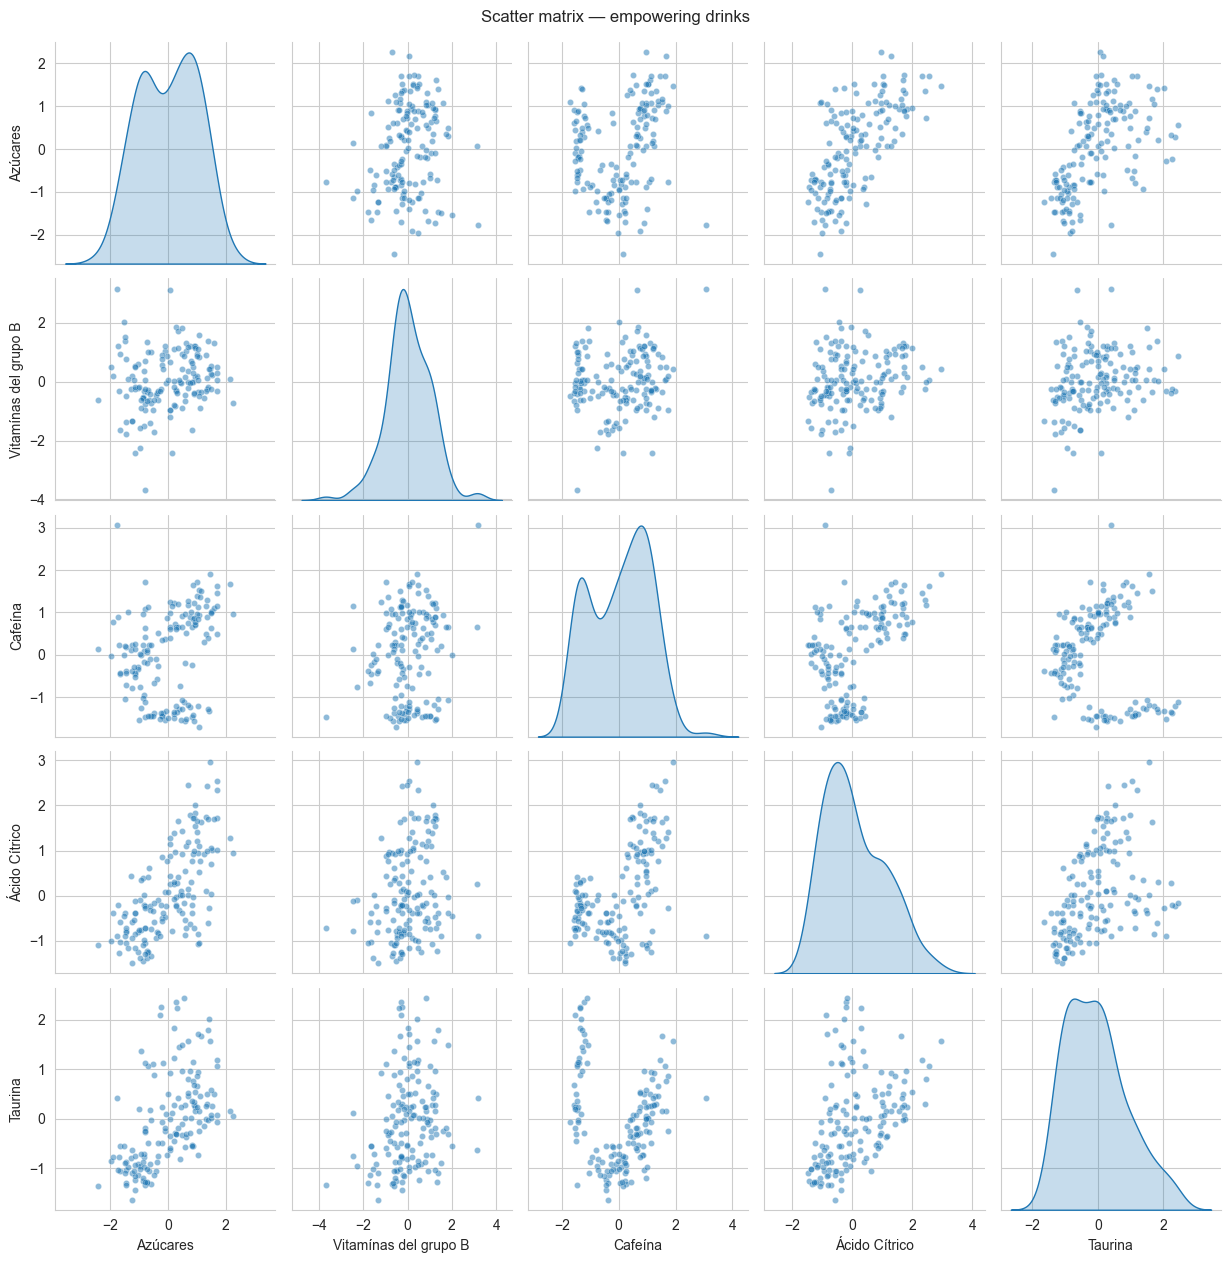

In [31]:
# Scatter matrix para ver relaciones entre pares de features
sns.pairplot(df, plot_kws={"alpha": 0.5, "s": 20}, diag_kind="kde")
plt.suptitle("Scatter matrix — empowering drinks", y=1.01)
plt.show()


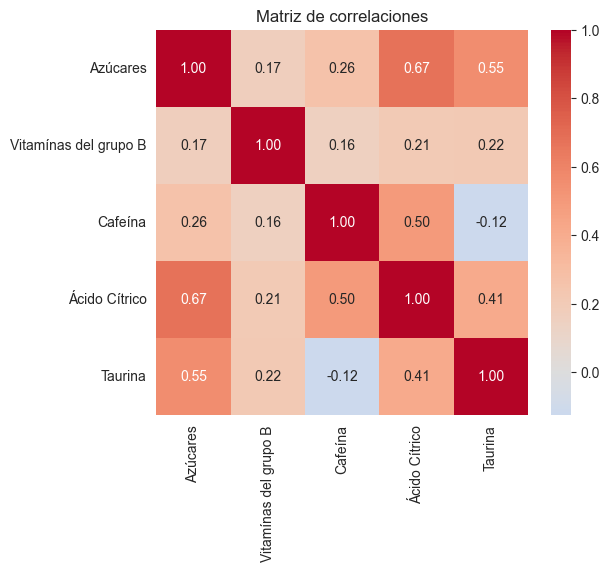

In [32]:
# Mapa de correlaciones
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()


**Conclusiones del EDA:**
- Los datos ya están escalados (media ≈ 0, std ≈ 1), por lo que **no necesitamos aplicar `StandardScaler`**.  
- No existen valores nulos.  
- Las correlaciones entre variables son bajas-moderadas, lo que indica que cada componente aporta información diferente; **usaremos las 5 features**.


### 4. Tratamiento de Features

In [33]:
# Los datos ya están normalizados; extraemos la matriz X
X = df.values
print("Shape de X:", X.shape)


Shape de X: (153, 5)


### 5 & 6. Modelo 1 — DBSCAN

#### Selección de hiperparámetros

Usamos el **gráfico de k-distancias** para elegir `eps`.  
Fijamos `k = min_samples - 1 = 4` (n_features = 5, regla heurística: min_samples ≥ n_features).  
El codo de la curva indica el valor óptimo de `eps`.


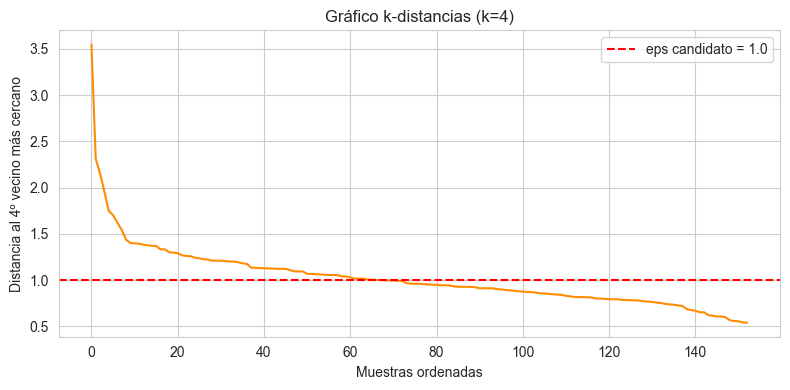

Percentil 80 k-dist: 0.794
Percentil 90 k-dist: 0.723


In [34]:
# Gráfico k-distancias para seleccionar eps
k = 4
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color="darkorange")
plt.axhline(y=1.0, color="red", linestyle="--", label="eps candidato = 1.0")
plt.xlabel("Muestras ordenadas")
plt.ylabel(f"Distancia al {k}º vecino más cercano")
plt.title("Gráfico k-distancias (k=4)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Percentil 80 k-dist: {np.percentile(k_dist, 20):.3f}")
print(f"Percentil 90 k-dist: {np.percentile(k_dist, 10):.3f}")


**Búsqueda de hiperparámetros:**  
Probamos varias combinaciones de `eps` y `min_samples` evaluando:
- Número de clusters obtenidos (objetivo: 3-5 según los químicos)
- Número de puntos ruido
- Silhouette Score (sobre los puntos no-ruido)


In [35]:
resultados = []
for eps in [0.8, 0.9, 1.0, 1.1, 1.2]:
    for min_s in [3, 4, 5, 6]:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X)
        labels = db.labels_
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clust >= 2:
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask])
        else:
            sil = None
        resultados.append({"eps": eps, "min_samples": min_s,
                           "n_clusters": n_clust, "n_noise": n_noise, "silhouette": sil})

res_df = pd.DataFrame(resultados)
# Mostrar solo los que cumplen la restricción 3-5 clusters
validos = res_df[(res_df["n_clusters"] >= 3) & (res_df["n_clusters"] <= 5)]
print(validos.sort_values("silhouette", ascending=False).to_string(index=False))


 eps  min_samples  n_clusters  n_noise  silhouette
 0.9            6           3       72    0.569541
 0.8            6           4      102    0.536268
 1.0            5           3       28    0.455092
 1.1            6           3       14    0.427146
 0.9            5           5       54    0.371509
 1.0            4           4       19    0.357269
 1.0            6           4       35    0.353715
 1.0            3           4       14    0.241311


**Hiperparámetros elegidos: `eps=1.0`, `min_samples=5`**  
- Produce **3 clusters**, dentro del rango esperado por los químicos.  
- Tiene el **mayor Silhouette Score** (≈ 0.455) entre las combinaciones válidas.  
- El número de puntos ruido (28, ≈18%) es razonable: DBSCAN los detecta como mezclas atípicas que no pertenecen a ningún grupo claro.


In [36]:
# Modelo DBSCAN final
dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan.fit(X)
labels_db = dbscan.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
print(f"Clusters encontrados: {n_clusters_db}")
print(f"Puntos ruido: {n_noise_db} ({n_noise_db/len(X)*100:.1f}%)")
mask = labels_db != -1
print(f"Silhouette Score (no-ruido): {silhouette_score(X[mask], labels_db[mask]):.3f}")


Clusters encontrados: 3
Puntos ruido: 28 (18.3%)
Silhouette Score (no-ruido): 0.455


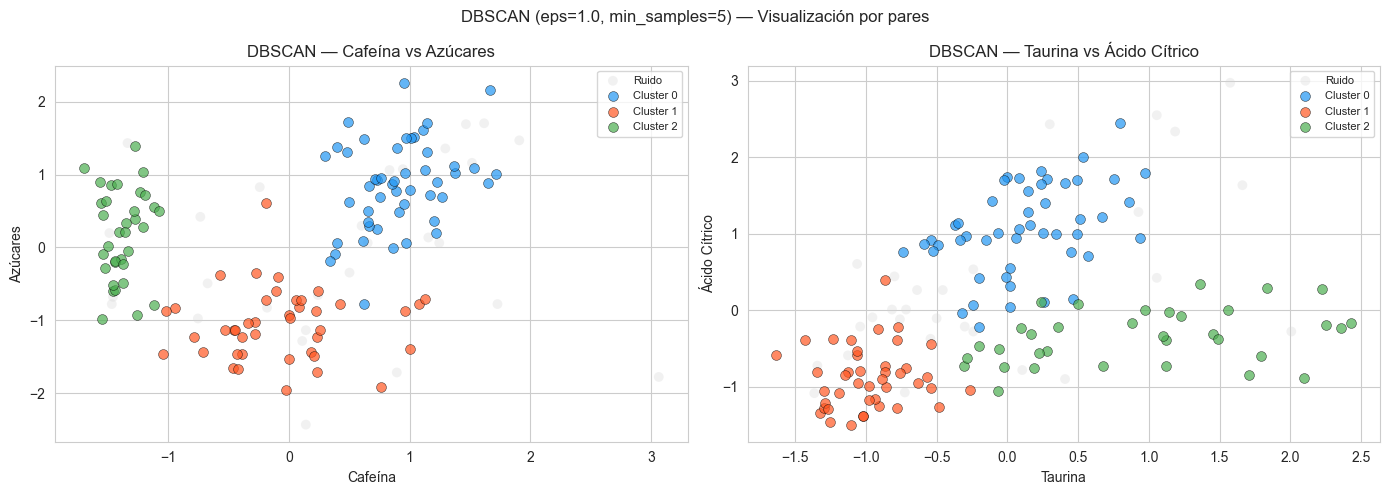

In [37]:
# Visualización DBSCAN — proyección en los dos primeros pares más informativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [("Cafeína", "Azúcares"), ("Taurina", "Ácido Cítrico")]
cols = df.columns.tolist()

colores = {-1: "lightgray", 0: "#2196F3", 1: "#FF5722", 2: "#4CAF50", 3: "#9C27B0", 4: "#FFC107"}
nombres_cl = {-1: "Ruido", 0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2", 3: "Cluster 3"}

for ax, (cx, cy) in zip(axes, pairs):
    for lbl in sorted(set(labels_db)):
        mask_lbl = labels_db == lbl
        ax.scatter(df.loc[mask_lbl, cx], df.loc[mask_lbl, cy],
                   c=colores[lbl], label=nombres_cl[lbl],
                   alpha=0.7 if lbl != -1 else 0.3,
                   edgecolors="k" if lbl != -1 else "none",
                   linewidths=0.4, s=50)
    ax.set_xlabel(cx)
    ax.set_ylabel(cy)
    ax.set_title(f"DBSCAN — {cx} vs {cy}")
    ax.legend(fontsize=8)

plt.suptitle("DBSCAN (eps=1.0, min_samples=5) — Visualización por pares", fontsize=12)
plt.tight_layout()
plt.show()


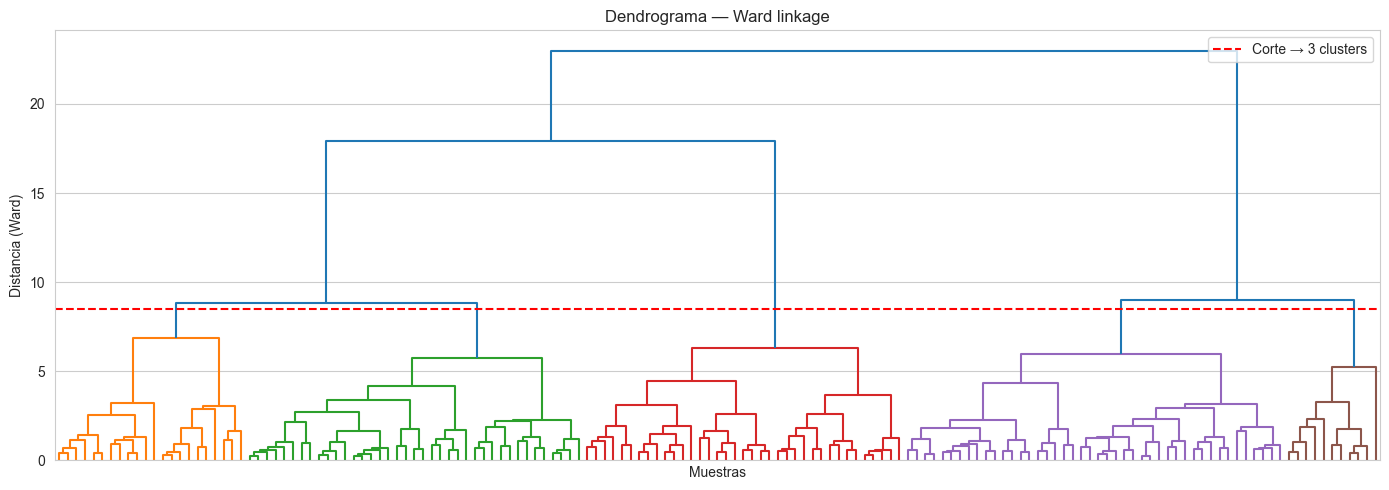

In [38]:
# Dendrograma completo para visualizar la estructura jerárquica
linked = linkage(X, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(linked,
           orientation="top",
           distance_sort="descending",
           show_leaf_counts=True,
           no_labels=True,
           color_threshold=8.5)
plt.axhline(y=8.5, color="red", linestyle="--", label="Corte → 3 clusters")
plt.title("Dendrograma — Ward linkage")
plt.xlabel("Muestras")
plt.ylabel("Distancia (Ward)")
plt.legend()
plt.tight_layout()
plt.show()


Búsqueda de n_clusters

In [39]:
# Grid de hiperparámetros para clustering jerárquico
res_hc = []
for n in [3, 4, 5]:
    for lk in ["ward", "complete", "average"]:
        hc = AgglomerativeClustering(n_clusters=n, linkage=lk)
        lbl = hc.fit_predict(X)
        sil = silhouette_score(X, lbl)
        res_hc.append({"n_clusters": n, "linkage": lk, "silhouette": round(sil, 3)})

res_hc_df = pd.DataFrame(res_hc).sort_values("silhouette", ascending=False)
print(res_hc_df.to_string(index=False))


 n_clusters  linkage  silhouette
          3     ward       0.384
          5  average       0.362
          4     ward       0.337
          4 complete       0.319
          5 complete       0.311
          5     ward       0.304
          3  average       0.298
          4  average       0.289
          3 complete       0.190


**Hiperparámetros elegidos: `n_clusters=3`, `linkage='ward'`**  
- Mejor Silhouette Score (≈ 0.384) entre todas las combinaciones.  
- **3 clusters** coincide con la cota inferior esperada por los químicos y con lo que produce DBSCAN.  
- `ward` minimiza la varianza intra-cluster, adecuado para clusters de tamaño similar y datos sin outliers.


In [40]:
# Modelo jerárquico final
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_hc = hc.fit_predict(X)

print("Distribución de clusters (Jerárquico):")
unique, counts = np.unique(labels_hc, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} muestras")
print(f"Silhouette Score: {silhouette_score(X, labels_hc):.3f}")


Distribución de clusters (Jerárquico):
  Cluster 0: 55 muestras
  Cluster 1: 61 muestras
  Cluster 2: 37 muestras
Silhouette Score: 0.384


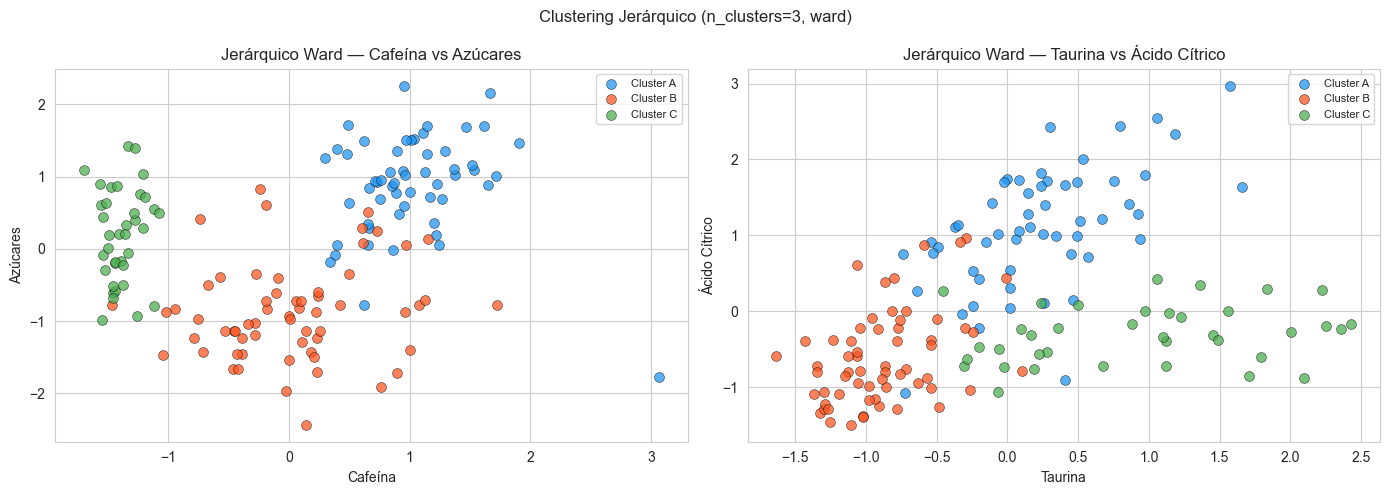

In [41]:
# Visualización Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_hc = {0: "#2196F3", 1: "#FF5722", 2: "#4CAF50"}
nombres_hc = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C"}

for ax, (cx, cy) in zip(axes, pairs):
    for lbl in sorted(set(labels_hc)):
        mask_lbl = labels_hc == lbl
        ax.scatter(df.loc[mask_lbl, cx], df.loc[mask_lbl, cy],
                   c=colores_hc[lbl], label=nombres_hc[lbl],
                   alpha=0.75, edgecolors="k", linewidths=0.4, s=50)
    ax.set_xlabel(cx)
    ax.set_ylabel(cy)
    ax.set_title(f"Jerárquico Ward — {cx} vs {cy}")
    ax.legend(fontsize=8)

plt.suptitle("Clustering Jerárquico (n_clusters=3, ward)", fontsize=12)
plt.tight_layout()
plt.show()


### 7. Discusión y comparación de modelos

| Métrica | DBSCAN (eps=1.0, min_s=5) | Jerárquico (n=3, ward) |
|---|---|---|
| Nº clusters | 3 | 3 |
| Puntos ruido | 28 (18%) | 0 |
| Silhouette | 0.455 (no-ruido) | 0.384 (todos) |

**¿Por qué la comparación es especulativa?**  
Porque se trata de aprendizaje **no supervisado**: no existe una «verdad de campo» que nos diga cuál segmentación es correcta. Las métricas como Silhouette miden cohesión interna, pero no si los grupos tienen significado real para los químicos.  
Lo que sí podemos decir:

- **DBSCAN** es más conservador: detecta 28 mezclas atípicas (ruido) que no encajan en ningún cluster. Eso puede ser información valiosa («estas mezclas son raras»).  
- **Jerárquico** asigna cada muestra a un grupo, lo que puede ser más cómodo operativamente, y el dendrograma permite ver que los clusters A y B son más similares entre sí que con C.  
- Ambos modelos convergen en **3 clusters**, lo que refuerza que esta segmentación refleja alguna estructura real en los datos.


### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [42]:
df_new = pd.read_csv("./data/new_experiments.csv", sep="|")

df2 = df_new.copy()
print(f"Nuevos experimentos: {df2.shape}")
df2.head()


Nuevos experimentos: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [43]:
# Re-entrenamos sobre el conjunto ampliado
X_all = np.vstack([X, df2.values])

hc_all = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_all = hc_all.fit_predict(X_all)

# Labels de los nuevos experimentos
labels_new = labels_all[len(X):]
print("Asignación de los nuevos experimentos:")
for i, lbl in enumerate(labels_new):
    print(f"  Experimento {i+1}: Cluster {lbl}")


Asignación de los nuevos experimentos:
  Experimento 1: Cluster 0
  Experimento 2: Cluster 0
  Experimento 3: Cluster 1
  Experimento 4: Cluster 1
  Experimento 5: Cluster 2
  Experimento 6: Cluster 2


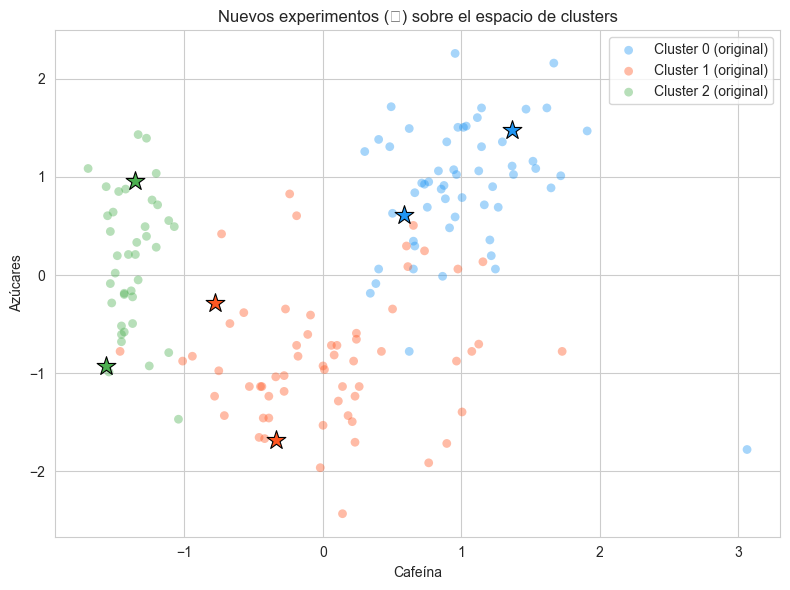

In [44]:
# Visualización — nuevos experimentos sobre el conjunto original
fig, ax = plt.subplots(figsize=(8, 6))

colores_all = {0: "#2196F3", 1: "#FF5722", 2: "#4CAF50"}

# Puntos originales
for lbl in sorted(set(labels_all[:len(X)])):
    mask = labels_all[:len(X)] == lbl
    ax.scatter(df.loc[mask, "Cafeína"], df.loc[mask, "Azúcares"],
               c=colores_all[lbl], alpha=0.4, s=40, edgecolors="none",
               label=f"Cluster {lbl} (original)")

# Nuevos experimentos
for i, lbl in enumerate(labels_new):
    ax.scatter(df2.iloc[i]["Cafeína"], df2.iloc[i]["Azúcares"],
               c=colores_all[lbl], s=200, marker="*",
               edgecolors="k", linewidths=0.8)

ax.set_xlabel("Cafeína")
ax.set_ylabel("Azúcares")
ax.set_title("Nuevos experimentos (★) sobre el espacio de clusters")
ax.legend()
plt.tight_layout()
plt.show()


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [46]:
df_power = pd.read_csv("./data/power_results.csv")
print(f"Shape power_results: {df_power.shape}")
print(df_power["class"].value_counts().sort_index())


Shape power_results: (159, 1)
class
1    58
2    62
3    39
Name: count, dtype: int64


In [47]:
# Las primeras 153 filas corresponden a los experimentos originales
# Las últimas 6 a los nuevos experimentos de la Parte II
y_true = df_power["class"].values

# Evaluamos el modelo jerárquico sobre el conjunto ampliado (n=159)
ari_hc = adjusted_rand_score(y_true, labels_all)
print(f"ARI — Clustering Jerárquico (todos los datos): {ari_hc:.3f}")

# DBSCAN: re-entrenamos sobre todos los datos y excluimos ruido para ARI
db_all = DBSCAN(eps=1.0, min_samples=5).fit(X_all)
labels_db_all = db_all.labels_
mask_no_noise = labels_db_all != -1
ari_db = adjusted_rand_score(y_true[mask_no_noise], labels_db_all[mask_no_noise])
n_noise_all = (labels_db_all == -1).sum()
print(f"ARI — DBSCAN (sin {n_noise_all} ruidos): {ari_db:.3f}")


ARI — Clustering Jerárquico (todos los datos): 0.807
ARI — DBSCAN (sin 19 ruidos): 0.913


Nivel energización   1   2   3
Cluster HC                    
0                   53   4   0
1                    5  57   0
2                    0   1  39


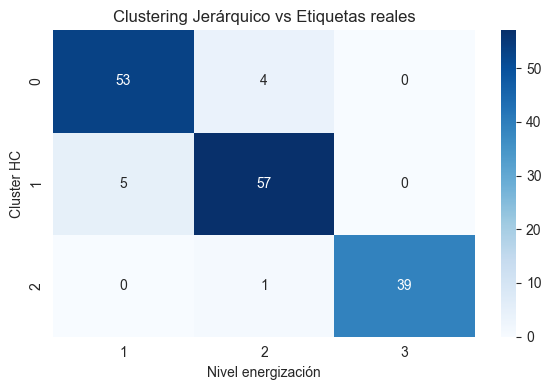

In [48]:
# Tabla de contingencia: clusters jerárquicos vs etiquetas reales
df_eval = pd.DataFrame({"cluster": labels_all, "power_class": y_true})
tabla = pd.crosstab(df_eval["cluster"], df_eval["power_class"],
                    rownames=["Cluster HC"], colnames=["Nivel energización"])
print(tabla)

# Mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Clustering Jerárquico vs Etiquetas reales")
plt.tight_layout()
plt.show()
